In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('/kaggle/input/datasets/peyonasayson/semi-cleaned-with-rating/SEMI-CLEANED(with Rating)_dataset.csv')

print("Semi-Clean Dataset loaded")
print(f"Shape: {df.shape}")
print(f"\nLabel distribution (CG vs OR):")
print(df['Label'].value_counts())

Semi-Clean Dataset loaded
Shape: (40405, 4)

Label distribution (CG vs OR):
Label
0    20215
1    20190
Name: count, dtype: int64


In [9]:
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(gpus) > 0}")
if gpus:
    print(f"GPU Device: {gpus[0]}")
    print("GPU is ready")

TensorFlow version: 2.19.0
GPU Available: True
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU is ready


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import re

# Character set (with uppercase)
charset = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789 .,!?;:\"'()-@#$%&"
char_to_idx = {ch: i+1 for i, ch in enumerate(charset)}
char_to_idx['<PAD>'] = 0
vocab_size = len(char_to_idx)
MAX_LEN = 512

print(f"Vocabulary size: {vocab_size}")
print(f"Max sequence length: {MAX_LEN}")

def minimal_clean(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    return text.strip()

def text_to_indices(text):
    text = minimal_clean(text)
    indices = [char_to_idx.get(ch, 0) for ch in text[:MAX_LEN]]
    if len(indices) < MAX_LEN:
        indices = indices + [0] * (MAX_LEN - len(indices))
    return indices[:MAX_LEN]

print("Converting reviews to character indices...")
X_review = np.array([text_to_indices(review) for review in df['Review']])
X_rating = df['Rating'].values.reshape(-1, 1)
y = df['Label'].values

print(f"X_review shape: {X_review.shape}")
print(f"X_rating shape: {X_rating.shape}")
print(f"Class distribution: CG={sum(y==0)}, OR={sum(y==1)}")

# Train/Validation/Test Split (80/10/10)
X_review_train, X_review_temp, X_rating_train, X_rating_temp, y_train, y_temp = train_test_split(
    X_review, X_rating, y, test_size=0.2, random_state=42, stratify=y
)

X_review_val, X_review_test, X_rating_val, X_rating_test, y_val, y_test = train_test_split(
    X_review_temp, X_rating_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_review_train)} (80%)")
print(f"Validation: {len(X_review_val)} (10%)")
print(f"Test: {len(X_review_test)} (10%)")

Vocabulary size: 80
Max sequence length: 512
Converting reviews to character indices...
X_review shape: (40405, 512)
X_rating shape: (40405, 1)
Class distribution: CG=20215, OR=20190
Train: 32324 (80%)
Validation: 4040 (10%)
Test: 4041 (10%)


In [11]:
from tensorflow.keras import regularizers

def create_model():
    # Review input
    review_input = layers.Input(shape=(MAX_LEN,), name='review_input')
    x = layers.Embedding(vocab_size, 128)(review_input)
    
    # Multi-scale convolutions with L2 regularization
    branch1 = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    branch2 = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    branch3 = layers.Conv1D(128, kernel_size=7, activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    
    x = layers.Concatenate()([branch1, branch2, branch3])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.2)(x)
    
    x = layers.Conv1D(256, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.2)(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])
    
    # Rating input
    rating_input = layers.Input(shape=(1,), name='rating_input')
    
    # Combine with L2 regularization
    combined = layers.Concatenate()([x, rating_input])
    combined = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(combined)
    combined = layers.Dropout(0.5)(combined)
    combined = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(combined)
    combined = layers.Dropout(0.5)(combined)
    output = layers.Dense(2, activation='softmax', name='output')(combined)
    
    model = models.Model(inputs=[review_input, rating_input], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Semi-Clean with rating model ready")

Semi-Clean with rating model ready


TRAINING SEMI-CLEAN WITH RATING


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review_input        │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 512, 128)  │     10,240 │ review_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 512, 128)  │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 512, 128)  │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 512, 128)  │    114,816 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 512, 384)  │          0 │ conv1d_5[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_6[0][0],   │
│                     │                   │            │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 384)  │      1,536 │ concatenate_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 256, 384)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 256, 384)  │          0 │ max_pooling1d_2[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 256, 256)  │    295,168 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256)  │      1,024 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 128, 256)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 128, 256)  │          0 │ max_pooling1d_3[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 128, 128)  │     98,432 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli

 Total params: 694,466 (2.65 MB)

 Trainable params: 692,930 (2.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.5655 - loss: 0.9071 - val_accuracy: 0.7215 - val_loss: 0.5954 - learning_rate: 5.0000e-04
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8540 - loss: 0.4609 - val_accuracy: 0.9166 - val_loss: 0.3178 - learning_rate: 5.0000e-04
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.8883 - loss: 0.3811 - val_accuracy: 0.9126 - val_loss: 0.3140 - learning_rate: 5.0000e-04
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9140 - loss: 0.3300 - val_accuracy: 0.9191 - val_loss: 0.3060 - learning_rate: 5.0000e-04
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9286 - loss: 0.2956 - val_accuracy: 0.9356 - val_loss: 0.2656 - learning_rate: 5.0000e-04
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9341 - loss: 0.2751 - val_accuracy: 0.9428 - val_loss: 0.2528 - learning_rate: 5.0000e-04
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/ste

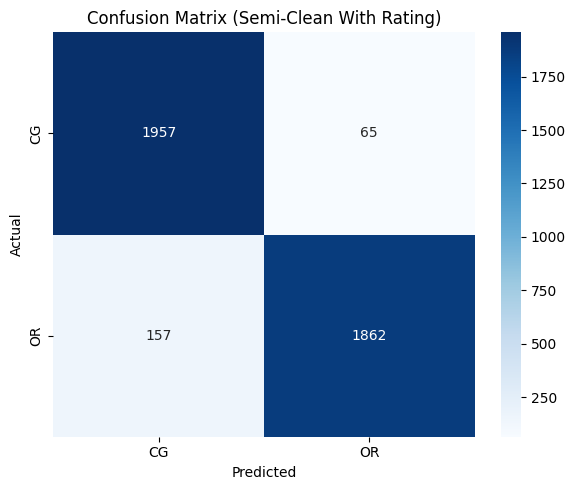

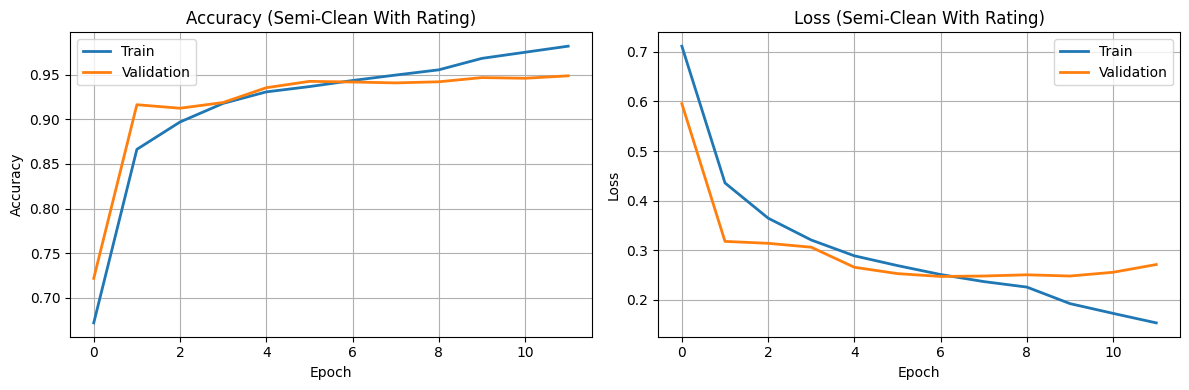

In [12]:
print("="*50)
print("TRAINING SEMI-CLEAN WITH RATING")
print("="*50)

model = create_model()
model.summary()

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

history = model.fit(
    [X_review_train, X_rating_train], y_train,
    validation_data=([X_review_val, X_rating_val], y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Test evaluation
test_loss, test_acc = model.evaluate([X_review_test, X_rating_test], y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Predictions
y_pred_proba = model.predict([X_review_test, X_rating_test])
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"\nPredicted CG (0): {(y_pred == 0).sum()}")
print(f"Predicted OR (1): {(y_pred == 1).sum()}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['CG', 'OR']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['CG', 'OR'], yticklabels=['CG', 'OR'])
plt.title('Confusion Matrix (Semi-Clean With Rating)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Subplot
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Accuracy (Semi-Clean With Rating)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Loss (Semi-Clean With Rating)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
print("="*50)
print("TEST YOUR OWN REVIEW")
print("CG = Computer Generated, OR = Original Review")
print("="*50)

def predict_review(review_text, rating=3.0):
    # Convert review to character indices
    indices = text_to_indices(review_text)
    review_input = np.array([indices])
    rating_input = np.array([[rating]])
    
    # Get prediction
    pred = model.predict([review_input, rating_input], verbose=0)
    
    # pred[0][0] = probability of CG, pred[0][1] = probability of OR
    if pred[0][0] > pred[0][1]:
        print(f"Result: COMPUTER GENERATED (CG)")
        print(f"Confidence: {pred[0][0]:.4f}")
    else:
        print(f"Result: ORIGINAL (OR)")
        print(f"Confidence: {pred[0][1]:.4f}")

print("\nType 'exit' to stop\n")

while True:
    user = input("Review: ")
    
    if user.lower() == 'exit':
        print("Done!")
        break
    
    if user.strip():
        predict_review(user)

TEST YOUR OWN REVIEW
CG = Computer Generated, OR = Original Review

Type 'exit' to stop



Review:  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance. 


Result: COMPUTER GENERATED (CG)
Confidence: 0.9579


Review:  This item arrived in excellent condition, the packaging was secure and the delivery was good.  


Result: COMPUTER GENERATED (CG)
Confidence: 0.8117


...

Result: COMPUTER GENERATED (CG)
Confidence: 0.8989


Review:  This is my purchase of the month. Thanks seller


Result: COMPUTER GENERATED (CG)
Confidence: 0.7760


Review:  exit


Done!
